### Normalize and correct sgRNA Log Fold Change data
#### adapted from Fortin et al, 2019
#### by Stefanus Bernard

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from function_to_normalize_sgrna_lfc import *

In [11]:
lfc_data = pd.read_csv("./yusa_data/KYLogfoldChange.csv", sep =',')
lfc_data = lfc_data.rename(columns={lfc_data.columns[0]: 'spacer'})
lfc_data.shape

(89477, 887)

In [12]:
# import library data
library_data = pd.read_csv("../../CRISPR-KO-library-refinement-pipeline/public_crispr_library/yusa_hcrispr_ko_grnas.tsv", sep ="\t", header = None)
library_data.columns = ['sgRNA', 'spacer', 'gene']
display(library_data.shape)

# import common essential genes
list_common_essential = import_common_essential()

(90709, 3)

In [13]:
lfc = pd.merge(lfc_data, library_data, how="left", on="spacer").set_index(['sgRNA', 'spacer', 'gene']).sort_values(by="gene")
lfc

,,,22RV1_c908R1_KY-1,22RV1_c908R2_KY-1,22RV1_c908R3_KY-1,231328_c908R1_KY-1,231328_c908R2_KY-1,231328_c908R3_KY-1,42MGBA_c907R1_KY-1,769P_c908R1_KY-1,769P_c908R2_KY-1,769P_c908R3_KY-1,...,U893_c903R3_KY-2,UWB12_c905R1_KY-1,UWB12_c905R2_KY-1,UWB12_c905R3_KY-1,YH13_c907R1_KY-1,YH13_c907R2_KY-1,no10_c907R1_KY-1,no10_c907R2_KY-1,no11_c907R1_KY-1,no11_c907R2_KY-1
sgRNA,spacer,gene,,,,,,,,,,,,,,,,,,,,,
sgA1BG_5,TGCTGACGGGTGACACCCA,A1BG,-0.273310,0.110016,-1.192116,-0.466902,-1.411102,-0.153236,0.570842,-0.013420,-0.581435,-0.270819,...,-0.123348,0.436301,-0.936277,0.869409,-1.422826,-1.112516,-0.125414,-0.356775,0.453915,0.168059
sgA1BG_4,CGGGGGTGATCCAGGACAC,A1BG,-1.566878,-1.480434,-0.859840,-1.197778,-0.237848,-1.550307,-0.017766,-0.935664,-1.413330,-2.165350,...,0.045287,-0.430938,0.253911,-1.097785,-3.460891,-0.488033,-0.958380,-1.097641,-1.016268,-1.124181
sgA1BG_2,TCAATGGTCACAGTAGCGC,A1BG,0.158508,0.149881,-0.264145,0.058822,-0.036999,0.572610,0.786872,-0.241328,-0.344076,-0.039140,...,0.185878,0.250302,0.110540,-0.484672,-0.116247,1.057776,0.366014,-0.036884,-0.595269,-0.146680
sgA1BG_3,CTGCAGCTACCGGACCGAT,A1BG,0.262659,0.545221,0.095092,-0.129753,1.079780,0.647933,1.242296,0.370546,0.309011,0.599970,...,0.166717,0.437877,0.510822,0.113278,0.104026,-0.661633,0.487030,0.641595,0.615123,1.000860
sgA1BG_1,GACTTCCAGCTACGGCGCG,A1BG,-0.771932,-0.498931,0.085523,-0.323509,-0.469305,-0.660434,0.456079,-0.369285,-0.001476,-0.806780,...,0.185562,0.077578,-0.450530,0.225586,-0.999880,-1.932872,0.183603,-0.217373,-0.444986,-0.122956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sgZZZ3_4,GACTACTGAGCCAGCTACA,ZZZ3,-0.260613,-0.146663,-0.478446,0.156638,-0.338119,-0.482134,-1.282607,-0.507700,-1.132078,-1.117868,...,-0.061729,-0.279785,-0.334583,-0.081540,-0.281082,0.040850,-0.759491,-0.592308,-0.731271,-0.828943
sgZZZ3_5,GCTGATTAACATGTTCCAC,ZZZ3,-0.761955,-0.751583,-0.256441,-0.714455,-0.751483,-1.023055,-0.325932,-1.480469,-1.928155,-1.499423,...,-0.357120,-0.112449,-0.623134,-0.510648,0.275270,-0.562352,-1.167843,-1.780863,-1.387892,-0.479315
sgZZZ3_3,GAAAACACCAATAACGAAC,ZZZ3,-0.763678,-0.751472,-0.616015,-1.182448,-0.607586,-0.815900,-0.702388,-0.618996,-1.882141,-1.626341,...,-0.744601,-0.211066,-0.344896,-0.150253,-0.165863,-5.085035,-3.194301,-0.358695,-0.624606,-2.292125


In [14]:
# normalize data by median
lfc_norm = lfc.apply(normalize_column, axis=0)

Scale factor:  1.685865660589488


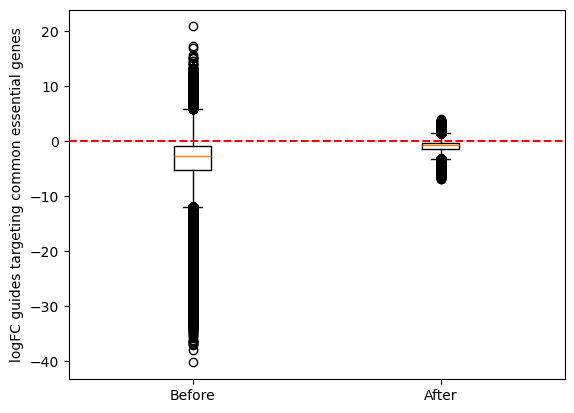

In [15]:
lfc_norm_scaled, list_common_essential = scale_essential(lfc)
sanity_check_scale_essential(lfc_norm, lfc_norm_scaled, list_common_essential)

In [16]:
lfc_norm_scaled_avg = mean_row(lfc_norm_scaled)
lfc_norm_scaled_avg = lfc_norm_scaled_avg.reset_index()
lfc_norm_scaled_avg

,sgRNA,spacer,gene,mean
0,sgA1BG_5,TGCTGACGGGTGACACCCA,A1BG,-0.108020
1,sgA1BG_4,CGGGGGTGATCCAGGACAC,A1BG,-0.546155
2,sgA1BG_2,TCAATGGTCACAGTAGCGC,A1BG,-0.092066
3,sgA1BG_3,CTGCAGCTACCGGACCGAT,A1BG,0.180892
4,sgA1BG_1,GACTTCCAGCTACGGCGCG,A1BG,-0.112341
...,...,...,...,...
89472,sgZZZ3_4,GACTACTGAGCCAGCTACA,ZZZ3,-0.177772
89473,sgZZZ3_5,GCTGATTAACATGTTCCAC,ZZZ3,-0.349169
89474,sgZZZ3_3,GAAAACACCAATAACGAAC,ZZZ3,-0.514995
89475,sgZZZ3_2,GTGGGACTACCTCTGGTAG,ZZZ3,-0.599491


In [17]:
lfc_norm_scaled_avg.to_csv("./output_normalized/yusa_normalized_lfc.csv", index=False)